### 1️⃣ Setup（環境 & import）

In [1]:
import os
import numpy as np
import pandas as pd
import tifffile as tiff
from skimage import measure
from tqdm import tqdm
import matplotlib.pyplot as plt

### 2️⃣ Config (只需要改這一區) 

In [2]:
DATA_ROOT = r"./zelda_label_batch"

PARENT_DIR = os.path.join(DATA_ROOT, "parents_label")
CHILD_DIR = os.path.join(DATA_ROOT, "children_label")
RAW_DIR = os.path.join(DATA_ROOT, "raw")

OUTPUT_DIR = os.path.join(DATA_ROOT, "results")

SCALE = (1.0, 1.0, 1.0)  # (z, y, x)

USE_MODE_PARENT = True  # max or compare

### 3️⃣ Utility functions（小工具）及 batch function (核心函數)

In [3]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="Failed to get convex hull image")

def get_valid_labels(label_img):
    labels = np.unique(label_img)
    return labels[labels != 0]

def relate_and_measure_batch(parents_labels, children_labels, original_image, scale=(1,1,1), use_mode=USE_MODE_PARENT):

    voxel_size = np.prod(scale)
    results = []

    labels = get_valid_labels(children_labels)

    for i in labels:

        mask = (children_labels == i)

        if not np.any(mask):
            continue

        single_child = children_labels * mask

        # parent mapping（改良版）
        parent_pixels = parents_labels[mask]
        parent_pixels = parent_pixels[parent_pixels > 0]

        if len(parent_pixels) > 0:
            if use_mode:
                parent_label = parent_pixels.max()
            else:
                parent_label = np.bincount(parent_pixels).argmax()

        else:
            parent_label = 0

        try:
            props = measure.regionprops_table(
                single_child,
                intensity_image=original_image,
                properties=[
                    'label','area','intensity_mean',
                    'intensity_min','intensity_max',
                    'axis_major_length','axis_minor_length',
                    'equivalent_diameter','extent','solidity',
                    'centroid', 'centroid_weighted'
                ]
            )

            row = {
                'Parent_label': parent_label,
                'Label': props['label'][0],
                'Area': props['area'][0] * scale[-1] * scale[-2],
                'Volume': props['area'][0] * voxel_size,
                'MFI': props['intensity_mean'][0],
            }

            # 將 props 字典中所有的值轉為純數值並合併到 row
            props_to_update = list(props.items())[3:]
            key_exclude = ['centroid-0', 'centroid-1', 'centroid-2', 
                           'centroid_weighted-0', 'centroid_weighted-1', 'centroid_weighted-2', ]
            row.update({key: val[0] for key, val in props_to_update if key not in key_exclude})
            row.update({
                'Centroid_X': props['centroid-2'][0] * scale[2],
                'Centroid_Y': props['centroid-1'][0] * scale[1],
                'Centroid_Z': props['centroid-0'][0] * scale[0],
                'Weighted_Centroid_X':props['centroid_weighted-2'][0] * scale[2],
                'Weighted_Centroid_Y':props['centroid_weighted-1'][0] * scale[1],
                'Weighted_Centroid_Z':props['centroid_weighted-0'][0] * scale[0]})

            results.append(row)

        except Exception as e:
            print(f"[Warning] label {i} failed: {e}")
    
    return pd.DataFrame(results)


### 4️⃣ 單張測試 (sanity check)

In [4]:
fname = sorted(os.listdir(PARENT_DIR))[0]

parent = tiff.imread(os.path.join(PARENT_DIR, fname))
child = tiff.imread(os.path.join(CHILD_DIR, fname))
raw = tiff.imread(os.path.join(RAW_DIR, fname))

print("Parent unique:", np.unique(parent)[:10])
print("Child unique:", np.unique(child)[:10])
print("Shape:", parent.shape, child.shape, raw.shape)

df = relate_and_measure_batch(parent, child, raw, SCALE)

print("單張測試完成。")
df.head()

Parent unique: [0 1 2 3 4 5 6 7 8 9]
Child unique: [0 1 2 3 4 5 6 7 8 9]
Shape: (6, 500, 500) (6, 500, 500) (6, 500, 500)


C:\Users\PC\.conda\envs\napari\Lib\site-packages\skimage\measure\_regionprops.py:704: RuntimeWarning: divide by zero encountered in scalar divide
  return self.area / self.area_convex


單張測試完成。


,Parent_label,Label,Area,Volume,MFI,intensity_min,intensity_max,axis_major_length,axis_minor_length,equivalent_diameter,extent,solidity,Centroid_X,Centroid_Y,Centroid_Z,Weighted_Centroid_X,Weighted_Centroid_Y,Weighted_Centroid_Z
0,2,1,4.0,4.0,3175.500000,2820.0,3456.0,2.236068,0.000000,1.969490,1.000000,inf,292.5,63.5,0.0,292.532908,63.517163,0.000000
1,2,2,1.0,1.0,3198.000000,3198.0,3198.0,0.000000,0.000000,1.240701,1.000000,inf,294.0,63.0,0.0,294.000000,63.000000,0.000000
2,0,3,10.0,10.0,3084.300000,2843.0,3312.0,3.204903,1.960575,2.673009,0.555556,1.0,285.3,64.1,0.7,285.291120,64.094543,0.716856
3,2,4,2.0,2.0,3004.000000,3001.0,3007.0,2.236068,0.000000,1.563185,1.000000,inf,292.0,65.5,0.0,292.000000,65.499501,0.000000
4,2,5,7.0,7.0,3283.142857,3035.0,3604.0,4.140393,0.000000,2.373376,0.777778,inf,294.0,65.0,0.0,293.974545,64.983030,0.000000


### 5️⃣ 單張視覺化檢視

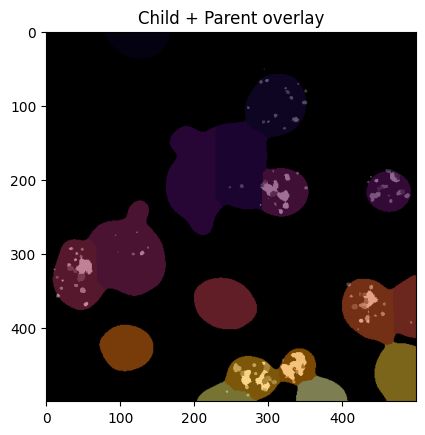

In [5]:
z = child.shape[0] // 2

plt.imshow(child[z], cmap='gray')
plt.imshow(parent[z], cmap='inferno', alpha=0.5)
plt.title("Child + Parent overlay")
plt.show()

### 6️⃣ Batch processing（主流程）

In [6]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

files = sorted(os.listdir(PARENT_DIR))

all_results = []

for f in tqdm(files):

    try:
        parent = tiff.imread(os.path.join(PARENT_DIR, f))
        child = tiff.imread(os.path.join(CHILD_DIR, f))
        raw = tiff.imread(os.path.join(RAW_DIR, f))

        df = relate_and_measure_batch(
            parent, child, raw,
            scale=SCALE,
            use_mode=USE_MODE_PARENT
        )

        df["filename"] = f
        all_results.append(df)

        df.to_csv(os.path.join(OUTPUT_DIR, f.replace(".tif", "_results.csv")), index=True)

    except Exception as e:
        print(f"[ERROR] {f}: {e}")
    print("Relate and measure batch finished")

  0%|                                                                                            | 0/8 [00:00<?, ?it/s]C:\Users\PC\.conda\envs\napari\Lib\site-packages\skimage\measure\_regionprops.py:704: RuntimeWarning: divide by zero encountered in scalar divide
  return self.area / self.area_convex
 12%|██████████▌                                                                         | 1/8 [00:02<00:17,  2.56s/it]C:\Users\PC\.conda\envs\napari\Lib\site-packages\skimage\measure\_regionprops.py:704: RuntimeWarning: divide by zero encountered in scalar divide
  return self.area / self.area_convex
 25%|█████████████████████                                                               | 2/8 [00:07<00:24,  4.05s/it]C:\Users\PC\.conda\envs\napari\Lib\site-packages\skimage\measure\_regionprops.py:704: RuntimeWarning: divide by zero encountered in scalar divide
  return self.area / self.area_convex
 38%|███████████████████████████████▌                                                    | 

### 7️⃣ 合併所有結果輸出

In [7]:
final_df = pd.concat(all_results, ignore_index=True)
final_df.to_csv(os.path.join(OUTPUT_DIR, "ALL_results.csv"), index=True)

### 8️⃣ 簡單分析呈現

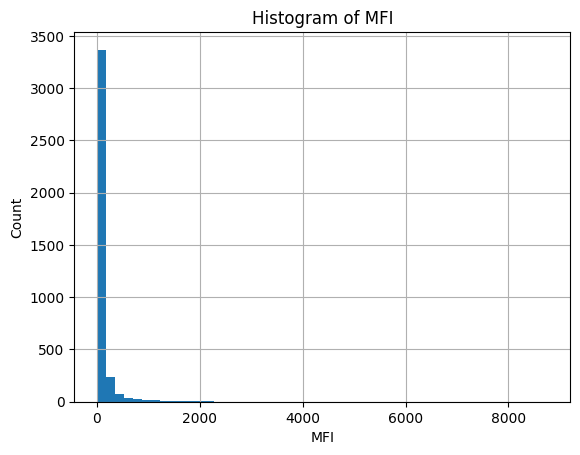

In [9]:
import matplotlib.pyplot as plt

plt.figure()
final_df["MFI"].hist(bins=50)

plt.title("Histogram of MFI")
plt.xlabel("MFI")
plt.ylabel("Count")

plt.show()